<a href="https://colab.research.google.com/github/AmandaElisa/gems-finder-tic-ia2/blob/main/dadosLimpos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Baixa o arquivo diretamente para o ambiente do Colab ao rodar a célula

!wget https://raw.githubusercontent.com/samarawwleticia/estudo_python/main/dataset.csv -O dataset.csv

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
df = pd.read_csv('dataset.csv')

df.info()

--2026-09-01 14:31:57--  https://raw.githubusercontent.com/samarawwleticia/estudo_python/main/dataset.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 20118244 (19M) [text/plain]
Saving to: ‘dataset.csv’

dataset.csv         100%[===================>]  19.19M  --.-KB/s    in 0.1s    

2026-09-01 14:31:57 (146 MB/s) - ‘dataset.csv’ saved [20118244/20118244]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   t

Primeiramente, vou remover a coluna Unnamed: 0 pois é uma coluna desnecessária.  

In [ ]:
df = df.drop(columns=['Unnamed: 0'])

Agora, vamos remover as linhas duplicadas do dataframes.



In [ ]:
df.drop_duplicates(keep='first', inplace=True)

Iriamos identificar e tratar os outliers mas percebemos que nesse caso não seria necessário devido aos 114 diferentes gêneros musicais que possuem características muito distintas entre si e portanto alertariam muitos outliers como em instrumentalness.


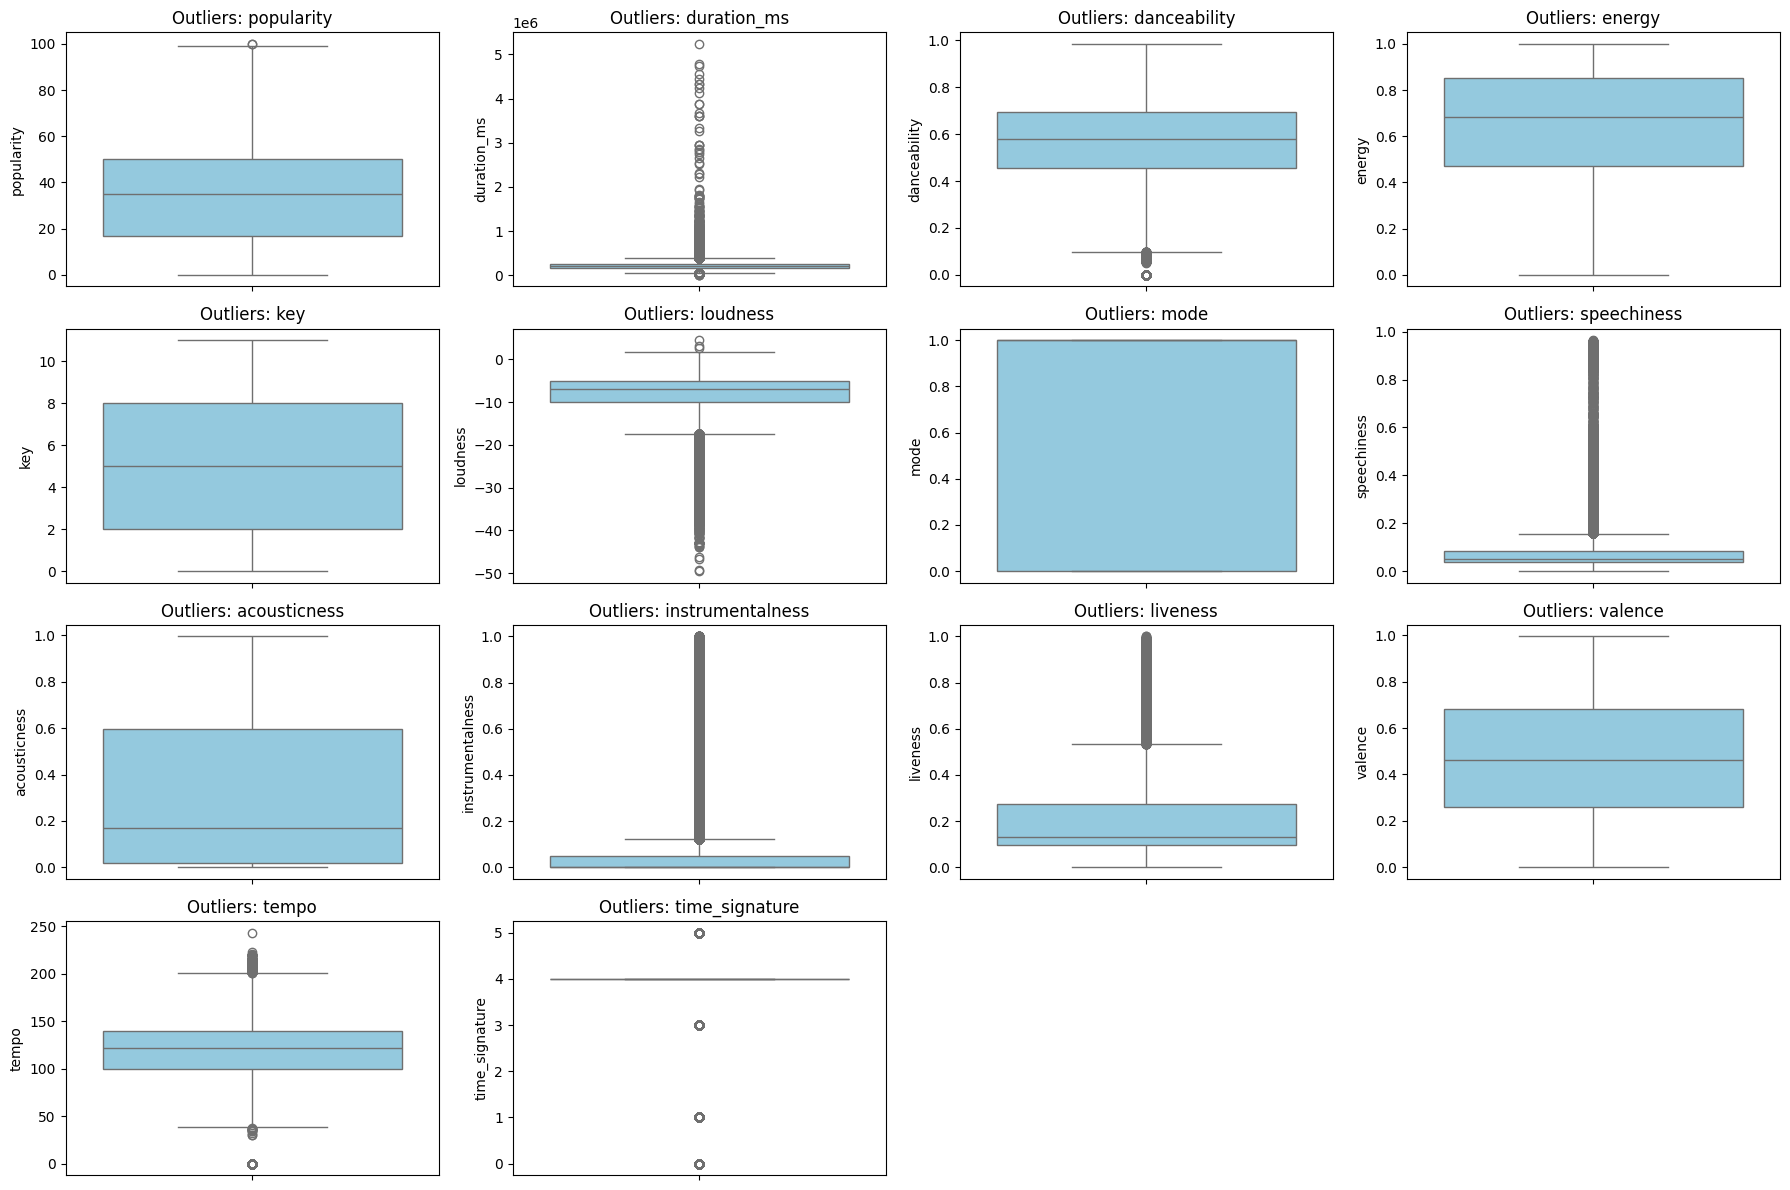

In [ ]:
# Selecionando apenas as colunas numéricas (excluindo booleanas e objetos)
colunas_numericas = df.select_dtypes(include=[np.number]).columns.tolist()

# Configurando a área de plotagem
plt.figure(figsize=(18, 12))

# Criando boxplots para todas as colunas numéricas para visualização rápida
for i, col in enumerate(colunas_numericas, 1):
    plt.subplot(4, 4, i)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Outliers: {col}')
    plt.tight_layout()

plt.show()

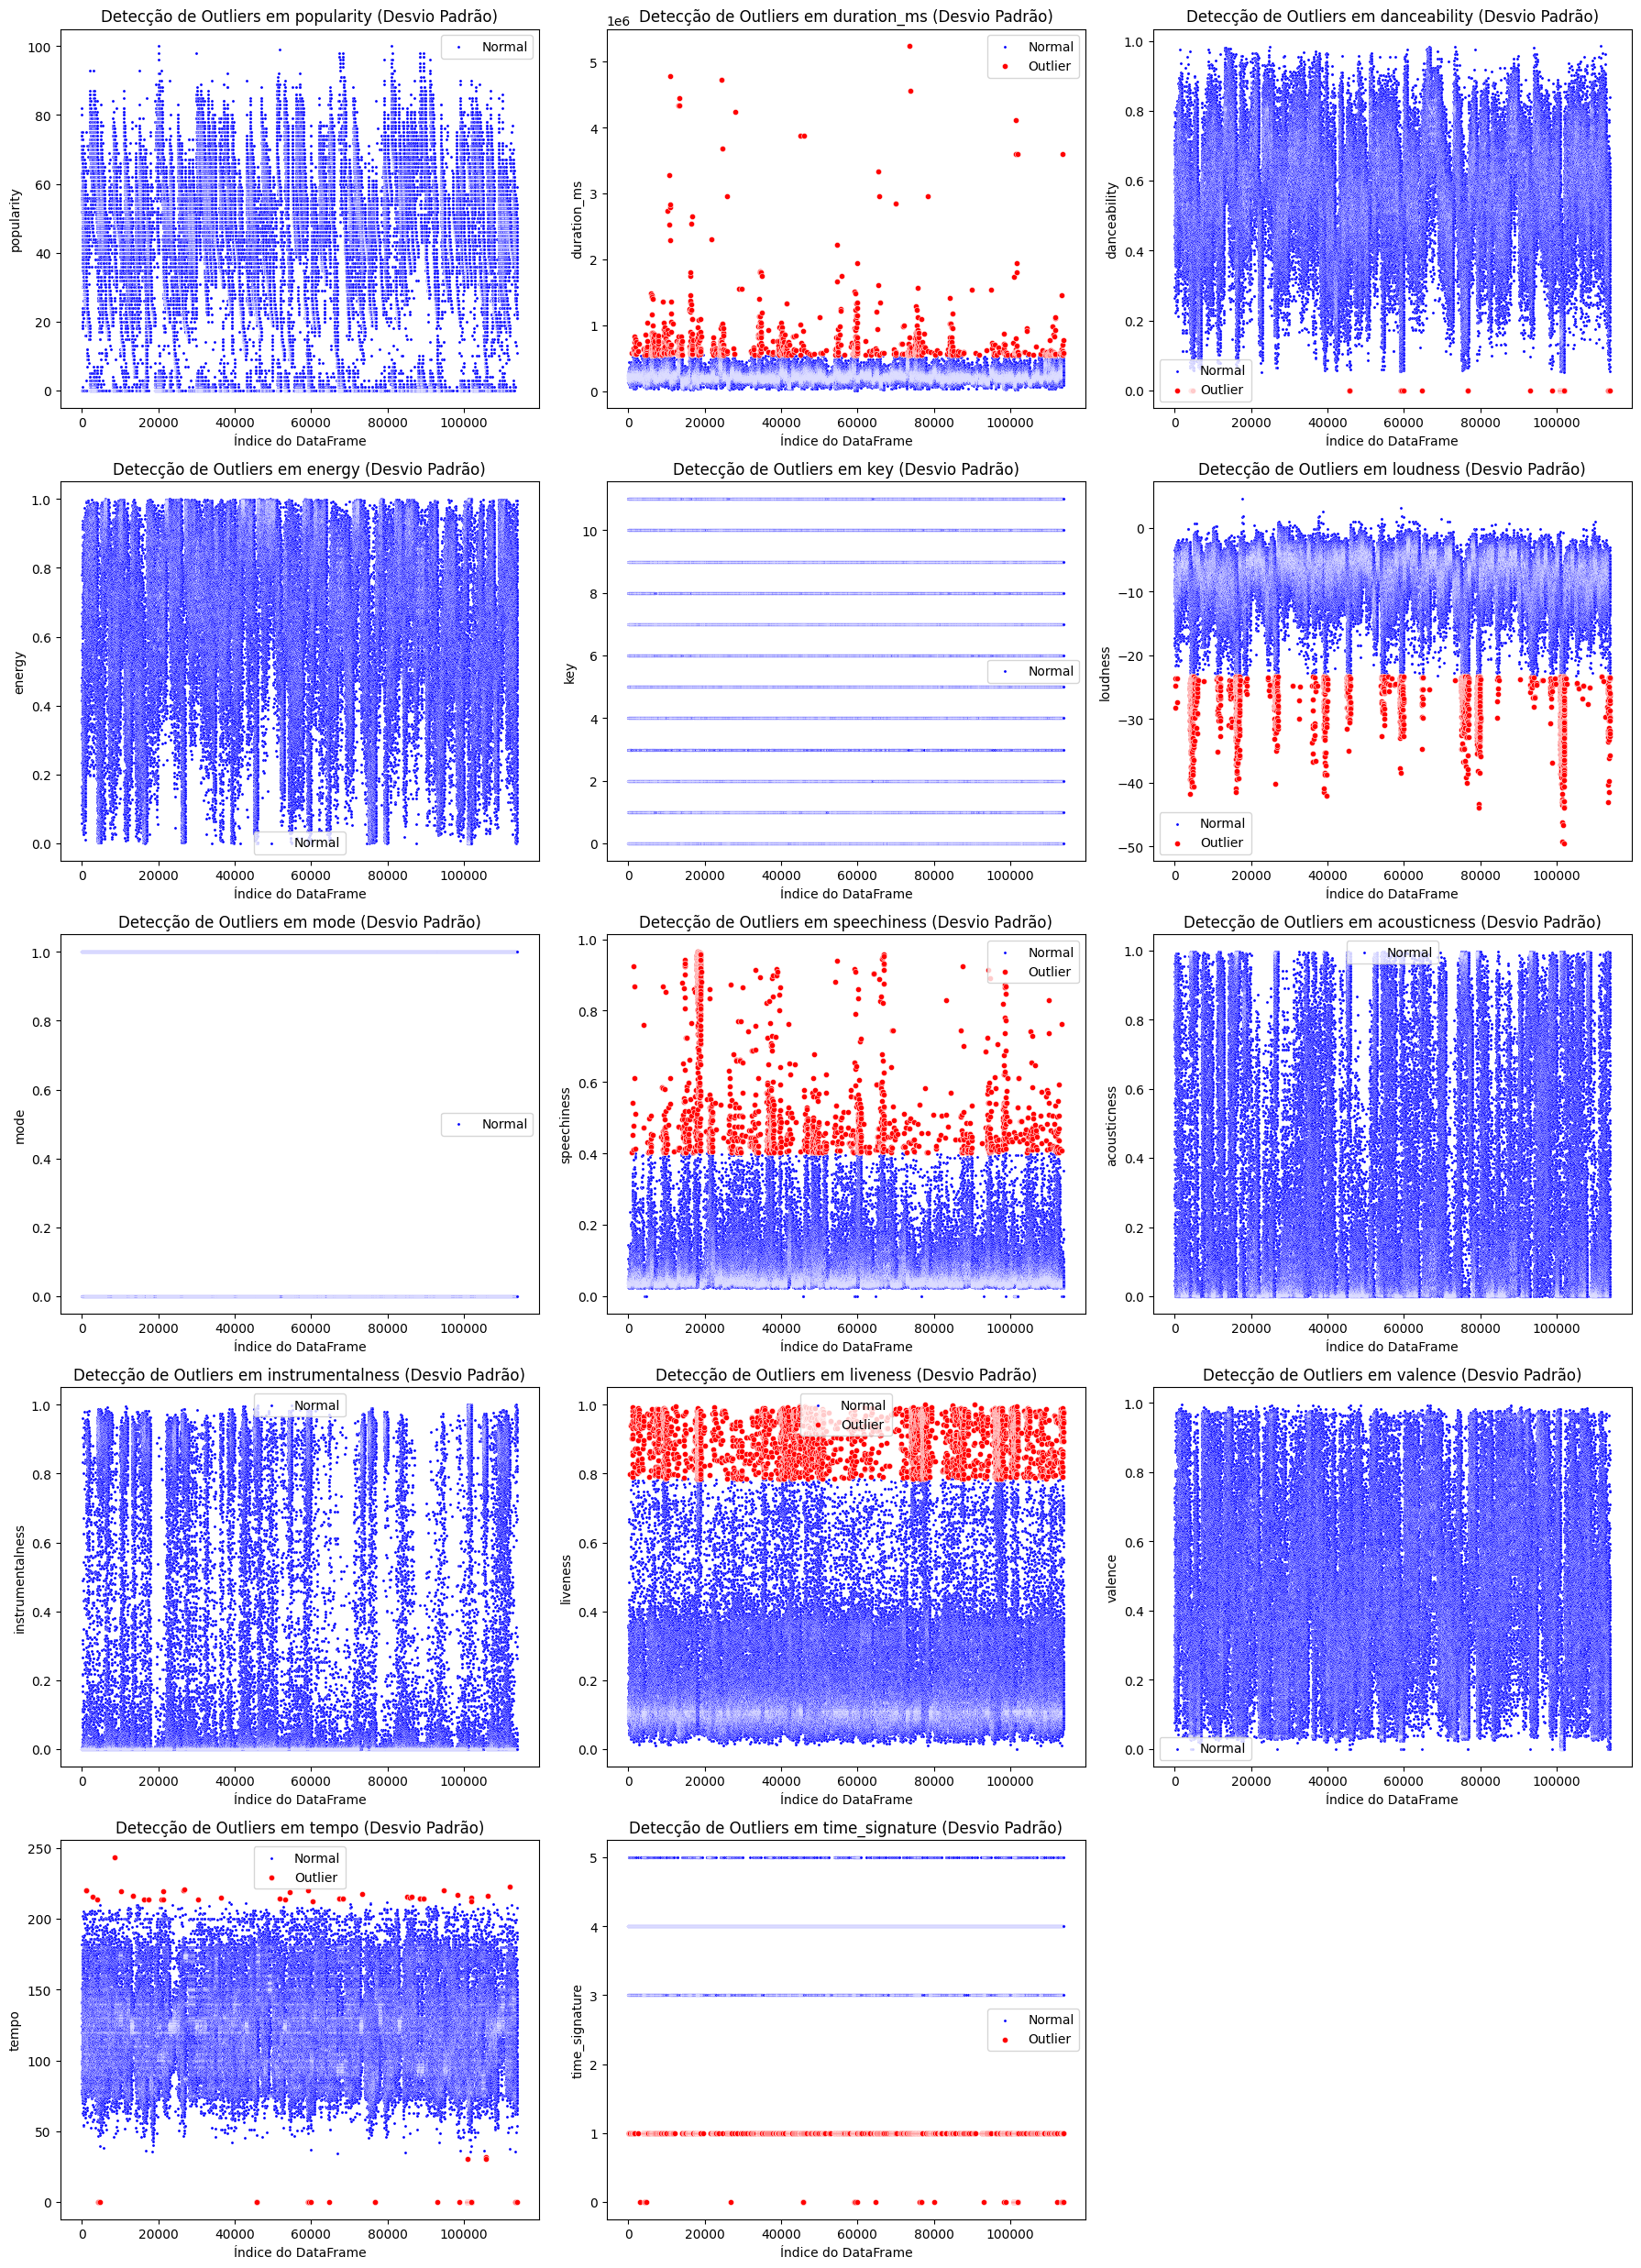

In [ ]:
# Seleciona apenas as colunas numéricas do DataFrame
numerical_cols = df.select_dtypes(include=['number']).columns

# Define o número de colunas para os subplots
num_cols = 3 # Você pode ajustar este valor conforme necessário
num_rows = (len(numerical_cols) + num_cols - 1) // num_cols

# Cria a figura e os subplots
fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 6, num_rows * 5))
axes = axes.flatten() # Achata o array de eixos para facilitar a iteração

for i, col in enumerate(numerical_cols):
    mean_val = df[col].mean()
    std_val = df[col].std()

    # Define os limites para outliers (por exemplo, 3 desvios padrão)
    lower_bound = mean_val - (3 * std_val)
    upper_bound = mean_val + (3 * std_val)

    # Identifica os outliers
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    # Cria um gráfico de dispersão para visualizar os dados e os outliers
    sns.scatterplot(x=df.index, y=df[col], ax=axes[i], label='Normal', color='blue', s=5)
    sns.scatterplot(x=outliers.index, y=outliers[col], ax=axes[i], label='Outlier', color='red', s=20)

    axes[i].set_title(f'Detecção de Outliers em {col} (Desvio Padrão)')
    axes[i].set_xlabel('Índice do DataFrame')
    axes[i].set_ylabel(col)
    axes[i].legend()

# Remove subplots vazios, se houver
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Vamos procurar dados nulos no dataset.

In [ ]:
df.isnull().sum()

,0
track_id,0
artists,1
album_name,1
track_name,1
popularity,0
duration_ms,0
explicit,0
danceability,0
energy,0
key,0


Identificando a célula em que os valores nulos estão.

In [ ]:
nulos = df[df["artists"].isnull()]
nulos

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
65900,1kR4gIb7nGxHPI3D2ifs59,NaN,NaN,NaN,0,0,False,0.501,0.583,7,-9.46,0,0.0605,0.69,0.00396,0.0747,0.734,138.391,4,k-pop


In [ ]:
# Removendo a linha com valor nulo

track_id_to_exclude = '1kR4gIb7nGxHPI3D2ifs59'
df = df[df['track_id'] != track_id_to_exclude]
print(f"Linha com track_id '{track_id_to_exclude}' removida. Novo tamanho do DataFrame: {df.shape}")

Linha com track_id '1kR4gIb7nGxHPI3D2ifs59' removida. Novo tamanho do DataFrame: (113549, 20)


Dados estão limpos e prontos!

Viés de Popularidade na Curadoria: Artistas Consolidados

In [ ]:
# 1. Calcula a popularidade máxima de cada artista no dataset
artist_max_pop = df.groupby('artists')['popularity'].max().reset_index()

# 2. Define a regra: se o pico de popularidade for > 65, é consolidado
artist_max_pop['is_consolidated'] = artist_max_pop['popularity'].apply(lambda x: 'Consolidado' if x > 65 else 'Independente')

# 3. Junta essa informação de volta no dataframe principal
df = df.merge(artist_max_pop[['artists', 'is_consolidated']], on='artists', how='left')

df.head()